<a href="https://colab.research.google.com/github/ywchanna2001/Protein_Conformational_Ensembles_Prediction/blob/dev/Protein_Conformational_Ensemble_Prediction_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#@title Input protein sequence(s) - cell 1
from google.colab import files
import os
import re
import hashlib
import random

from sys import version_info
python_version = f"{version_info.major}.{version_info.minor}"

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

query_sequence = 'PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK' #@param {type:"string"}
#@markdown  - Use `:` to specify inter-protein chainbreaks for **modeling complexes** (supports homo- and hetro-oligomers). For example **PI...SK:PI...SK** for a homodimer
jobname = 'Test1_by_channa' #@param {type:"string"}
# number of models to use
num_relax = 5 #@param [0, 1, 5] {type:"raw"}
#@markdown - specify how many of the top ranked structures to relax using amber
template_mode = "none" #@param ["none", "pdb100","custom"]
#@markdown - `none` = no template information is used. `pdb100` = detect templates in pdb100 (see [notes](#pdb100)). `custom` - upload and search own templates (PDB or mmCIF format, see [notes](#custom_templates))

use_amber = num_relax > 0

# remove whitespaces
query_sequence = "".join(query_sequence.split())

basejobname = "".join(jobname.split())
basejobname = re.sub(r'\W+', '', basejobname)
jobname = add_hash(basejobname, query_sequence)

# check if directory with jobname exists.
# If folder exist return 'False'
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True
if not check(jobname):
  n = 0
  while not check(f"{jobname}_{n}"): n += 1
  jobname = f"{jobname}_{n}"

# make directory to save results
os.makedirs(jobname, exist_ok=True)

# save queries
queries_path = os.path.join(jobname, f"{jobname}.csv")
with open(queries_path, "w") as text_file:
  text_file.write(f"id,sequence\n{jobname},{query_sequence}")

if template_mode == "pdb100":
  use_templates = True
  custom_template_path = None
elif template_mode == "custom":
  custom_template_path = os.path.join(jobname,f"template")
  os.makedirs(custom_template_path, exist_ok=True)
  uploaded = files.upload()
  use_templates = True
  for fn in uploaded.keys():
    os.rename(fn,os.path.join(custom_template_path,fn))
else:
  custom_template_path = None
  use_templates = False

print("jobname",jobname)
print("sequence",query_sequence)
print("length",len(query_sequence.replace(":","")))

jobname Test1_by_channa_a5e17
sequence PIAQIHILEGRSDEQKETLIREVSEAISRSLDAPLTSVRVIITEMAKGHFGIGGELASK
length 59


In [2]:
#@title Install dependencies - cell 2
%%time
import os
USE_AMBER = use_amber
USE_TEMPLATES = use_templates
PYTHON_VERSION = python_version

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so /usr/local/lib/python3.*/dist-packages/tensorflow/lite/python/*/*.so")
  os.system("touch COLABFOLD_READY")

if USE_AMBER or USE_TEMPLATES:
  if not os.path.isfile("CONDA_READY"):
    print("installing conda...")
    os.system("wget -qnc https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh")
    os.system("bash Miniforge3-Linux-x86_64.sh -bfp /usr/local")
    os.system("mamba config --set auto_update_conda false")
    os.system("touch CONDA_READY")

if USE_TEMPLATES and not os.path.isfile("HH_READY") and USE_AMBER and not os.path.isfile("AMBER_READY"):
  print("installing hhsuite and amber...")
  os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
  os.system("touch HH_READY")
  os.system("touch AMBER_READY")
else:
  if USE_TEMPLATES and not os.path.isfile("HH_READY"):
    print("installing hhsuite...")
    os.system(f"mamba install -y -c conda-forge -c bioconda kalign2=2.04 hhsuite=3.3.0 python='{PYTHON_VERSION}'")
    os.system("touch HH_READY")
  if USE_AMBER and not os.path.isfile("AMBER_READY"):
    print("installing amber...")
    os.system(f"mamba install -y -c conda-forge openmm=8.2.0 python='{PYTHON_VERSION}' pdbfixer")
    os.system("touch AMBER_READY")

installing colabfold...
installing conda...
installing amber...
CPU times: user 6.11 ms, sys: 1.48 ms, total: 7.6 ms
Wall time: 1min 26s


In [3]:
#@title MSA Options : cell 3
#@markdown ### MSA options (custom MSA upload, single sequence, pairing mode)
msa_mode = "mmseqs2_uniref_env" #@param ["mmseqs2_uniref_env", "mmseqs2_uniref","single_sequence","custom"]
pair_mode = "unpaired_paired" #@param ["unpaired_paired","paired","unpaired"] {type:"string"}
#@markdown - "unpaired_paired" = pair sequences from same species + unpaired MSA, "unpaired" = seperate MSA for each chain, "paired" - only use paired sequences.

# decide which a3m to use
if "mmseqs2" in msa_mode:
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

# we don't use these options(custom, single_sequence) for this research
elif msa_mode == "custom":
  a3m_file = os.path.join(jobname,f"{jobname}.custom.a3m")
  if not os.path.isfile(a3m_file):
    custom_msa_dict = files.upload()
    custom_msa = list(custom_msa_dict.keys())[0]
    header = 0
    import fileinput
    for line in fileinput.FileInput(custom_msa,inplace=1):
      if line.startswith(">"):
         header = header + 1
      if not line.rstrip():
        continue
      if line.startswith(">") == False and header == 1:
         query_sequence = line.rstrip()
      print(line, end='')

    os.rename(custom_msa, a3m_file)
    queries_path=a3m_file
    print(f"moving {custom_msa} to {a3m_file}")

else:
  a3m_file = os.path.join(jobname,f"{jobname}.single_sequence.a3m")
  with open(a3m_file, "w") as text_file:
    text_file.write(">1\n%s" % query_sequence)

# MODULE 1:  MSA GENERATION

In [4]:
#@title MSA GENERATION : cell 4
import time
import colabfold
from colabfold.colabfold import run_mmseqs2
import colabfold.colabfold as cf_module

# In this research we always use mmseques2_uniref_env as the msa option
search_mode = msa_mode
use_env = "env" in search_mode

print(f"Target Sequence: {query_sequence[:30]}...")
print(f"Job Name: {jobname}")

# Delete any stale cached .a3m file so the API is actually called
a3m_cache = os.path.join(jobname, f"{jobname}.a3m")
if os.path.isfile(a3m_cache):
    os.remove(a3m_cache)
    print("Removed cached .a3m — forcing fresh API search...")

print("Status: Contacting MMseqs2 server (this can take 1–3 minutes)...")

try:
    # Capture result correctly — run_mmseqs2 returns a LIST of a3m content strings

    result = run_mmseqs2(
        x=query_sequence,
        prefix=jobname,
        use_env=use_env,
        use_filter=True,           # Required for proper hit filtering. This removes redundant and low quality hits
        use_pairing=False,
        user_agent= "qevagna@gmail.com"
    )

    # print("result: ",result)

    # Flatten the result into individual lines correctly
    # result is a list of strings; each string can be a full a3m block
    if isinstance(result, list):
        a3m_lines = "\n".join(result).splitlines(keepends=True)
    else:
        a3m_lines = result.splitlines(keepends=True)

    # Count sequences properly (lines starting with '>')
    num_seqs = sum(1 for line in a3m_lines if line.startswith(">"))

    print(f"Total lines in result: {len(a3m_lines)}")
    print(f"Sequences found (headers): {num_seqs}")

    if num_seqs <= 1:
        print("❌ ERROR: Server returned 0 hits.")
        print("Debugging info:")
        print("".join(a3m_lines[:10]))  # Show first 10 lines for diagnosis
        print("\nPossible causes:")
        print("  - MMseqs2 API server is down or overloaded (try again in 1 min)")
        print("  - Sequence too short/non-standard for database hits")
        print("  - Network issue in Colab (try Runtime > Restart and run all)")
    else:
        # Save valid MSA
        msa_module_dir = "research_msa_output"
        os.makedirs(msa_module_dir, exist_ok=True)
        msa_file_path = os.path.join(msa_module_dir, f"{jobname}.a3m")

        with open(msa_file_path, "w") as f:
            f.writelines(a3m_lines)

        print(f"✅ SUCCESS: {num_seqs} sequences saved to {msa_file_path}")

except Exception as e:
    print(f"❌ SERVER ERROR: {e}")
    import traceback
    traceback.print_exc()

Target Sequence: PIAQIHILEGRSDEQKETLIREVSEAISRS...
Job Name: Test1_by_channa_a5e17
Status: Contacting MMseqs2 server (this can take 1–3 minutes)...


COMPLETE: 100%|██████████| 150/150 [elapsed: 00:01 remaining: 00:00]

Total lines in result: 16152
Sequences found (headers): 8076
✅ SUCCESS: 8076 sequences saved to research_msa_output/Test1_by_channa_a5e17.a3m


In [5]:
def plot_msa_corrected(feature_dict, sort_lines=True, dpi=100):
    import matplotlib.pyplot as plt
    import numpy as np

    # Extract data from  feature_dict
    msa = feature_dict["msa"]
    # 21 is the standard GAP_IDX
    non_gaps = (msa != 21).astype(float)
    non_gaps[non_gaps == 0] = np.nan

    # Calculate identity if not pre-calculated
    seq = msa[0]
    # Simple identity calculation
    identity = np.nanmean(msa == seq, axis=1)

    # Prepare lines for plotting (identity * non_gap_mask)
    lines = non_gaps * identity[:, None]

    # Sort lines by identity
    lines = lines[np.argsort(identity)]

    # 4. Rendering
    plt.figure(figsize=(10, 8), dpi=dpi)
    plt.title("Sequence coverage")

    # Plotting the matrix
    plt.imshow(lines,
              interpolation='nearest', aspect='auto',
              cmap="rainbow_r", vmin=0, vmax=1, origin='lower',
              extent=(0, lines.shape[1], 0, lines.shape[0]))

    # Add coverage curve (count non-NaN values per column)
    coverage = np.nansum(~np.isnan(lines), axis=0)
    plt.plot(coverage, color='black', lw=1.5)

    plt.xlim(0, lines.shape[1])
    plt.ylim(0, lines.shape[0])
    plt.colorbar(label="Sequence identity to query")
    plt.xlabel("Positions")
    plt.ylabel("Sequences")
    plt.show()

✅ 'input_features' created. Shape: (8076, 59)
Plotting sequence coverage...


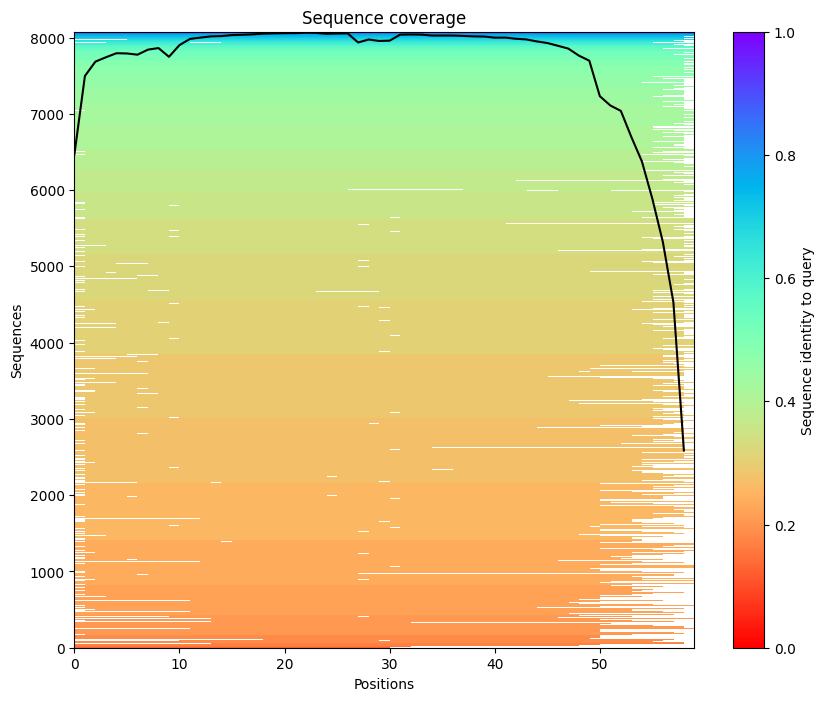

In [6]:
# Build and Plot
import numpy as np
import matplotlib.pyplot as plt

# 1. Parse A3M data
sequences = []
current_seq =[]
for line in a3m_lines:
    line = line.strip()
    if not line or line.startswith("#"): continue
    if line.startswith(">"):
        if current_seq: sequences.append("".join(current_seq))
        current_seq =[]
    else:
        current_seq.append("".join(c if (c.isupper() or c == "-") else "" for c in line))
if current_seq: sequences.append("".join(current_seq))

# 2. Build the Matrix
query_len = len(sequences[0])
GAP_IDX = 21
res_map = {c: i for i, c in enumerate("ARNDCQEGHILKMFPSTWYV")}
msa_list = [[res_map.get(c.upper(), GAP_IDX) for c in seq[:query_len]] for seq in sequences]
# Pad shorter sequences
msa_arr = np.array([row + [GAP_IDX]*(query_len-len(row)) for row in msa_list], dtype=np.int32)

# 3. Create the global input_features dictionary
input_features = {
    "msa": msa_arr,
    "num_alignments": np.sum(msa_arr != GAP_IDX, axis=0).astype(np.int32)
}

print(f"✅ 'input_features' created. Shape: {input_features['msa'].shape}")

# 4. Run the plotting function
print("Plotting sequence coverage...")
plot_msa_corrected(input_features)

# MODULE 2: DBSCAN CLUSTERING

In [ ]:
import os
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. LOAD DATA DIRECTLY FROM DISK
# This ensures Module 2 works even if you restart the notebook
msa_file_path = f"research_msa_output/{jobname}.a3m"

if os.path.exists(msa_file_path):
    print(f"Loading MSA from disk: {msa_file_path}")

    with open(msa_file_path, "r") as f:
        lines = f.readlines()

    # Parse text sequences into numerical matrix
    processed_seqs = []
    for line in lines:
        line = line.strip()
        if not line or line.startswith(">") or line.startswith("#"):
            continue
        # Remove insertions (lowercase)
        clean_seq = "".join([c for c in line if not c.islower()])
        if clean_seq:
            processed_seqs.append(clean_seq)

    map_str = "ARNDCQEGHILKMFPSTWYV-"
    res_map = {res: i for i, res in enumerate(map_str)}
    msa_indices = [[res_map.get(res.upper(), 21) for res in seq] for seq in processed_seqs]
    msa_arr = np.array(msa_indices)

    print(f"✅ Data Ready. Matrix Shape: {msa_arr.shape} (Sequences, Length)")

    # 2. DIMENSIONALITY REDUCTION (PCA)
    # Standardizing is required for DBSCAN to calculate densities correctly
    scaled_msa = StandardScaler().fit_transform(msa_arr)
    n_pc = min(10, msa_arr.shape[0], msa_arr.shape[1])
    pca = PCA(n_components=n_pc)
    msa_pca = pca.fit_transform(scaled_msa)

    # 3. DBSCAN CLUSTERING
    # Tuning: eps (distance) and min_samples (min density)
    # For research, we'll experiment with these values
    db = DBSCAN(eps=1.2, min_samples=5)
    cluster_labels = db.fit_predict(msa_pca)

    # 4. RESULTS SUMMARY
    unique_labels = set(cluster_labels)
    n_clusters = len(unique_labels) - (1 if -1 in cluster_labels else 0)
    print(f"✅ Found {n_clusters} clusters.")
    print(f"✅ Noise sequences (Label -1): {list(cluster_labels).count(-1)}")

    # 5. VISUALIZATION
    plt.figure(figsize=(10, 6))
    scatter = plt.scatter(msa_pca[:, 0], msa_pca[:, 1], c=cluster_labels, cmap='Set1', s=25, alpha=0.7)
    plt.title(f"Conformational Landscape Cluster Map: {jobname}")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.colorbar(scatter, label="Cluster ID (-1 is Noise)")
    plt.show()

else:
    print(f"❌ Error: File not found at {msa_file_path}. Please run Module 1 again.")

In [ ]:
# --- IMPROVED VISUALIZATION FOR RESEARCH REPORT ---
import seaborn as sns

# 1. Statistics - How many sequences per state?
unique, counts = np.unique(cluster_labels, return_counts=True)
cluster_stats = dict(zip(unique, counts))
print("--- Cluster Distribution ---")
for cluster_id, count in cluster_stats.items():
    label = "Noise" if cluster_id == -1 else f"State {cluster_id}"
    print(f"{label}: {count} sequences ({count/len(cluster_labels)*100:.1f}%)")

# 2. Dual-View Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# View A: Density Map (All points with transparency)
# Using 's=5' and 'alpha=0.3' allows us to see through the 'red blob'
scatter1 = ax1.scatter(msa_pca[:, 0], msa_pca[:, 1], c=cluster_labels,
                       cmap='Set1', s=5, alpha=0.3)
ax1.set_title(f"Sequence Density Map\n(All {len(cluster_labels)} sequences)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")

# View B: Focused View (Excluding the dominant Cluster 0)
# This allows you to see the "alternative states" clearly
mask = (cluster_labels != 0) & (cluster_labels != -1)
if np.any(mask):
    scatter2 = ax2.scatter(msa_pca[mask, 0], msa_pca[mask, 1], c=cluster_labels[mask],
                           cmap='tab20', s=30, alpha=0.8)
    ax2.set_title("Alternative States\n(Cluster 0 and Noise hidden)")
    plt.colorbar(scatter2, ax=ax2, label="Alternative State ID")
else:
    ax2.text(0.5, 0.5, "No significant alternative states found\nat current DBSCAN settings",
             ha='center', va='center')
    ax2.set_title("Alternative States View")

ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")

plt.tight_layout()
plt.show()

# Testing official DBSCAN logic from AFCluster-cell 10

In [7]:
import numpy as np
from Bio import SeqIO

#This function calculates the "most common" residue at every single position
#in a set of sequences to generate a single representative sequence.
def consensusVoting(seqs):
    consensus = ""
    residues = "ARNDCQEGHILKMFPSTWYV-"
    n_chars = len(seqs[0])
    for i in range(n_chars):
        baseArray = [x[i] for x in seqs]
        baseCount = np.array([baseArray.count(a) for a in list(residues)])
        vote = np.argmax(baseCount)
        consensus += residues[vote]
    return consensus

def encode_seqs(seqs, max_len=108, alphabet="ARNDCQEGHILKMFPSTWYV-"):
    # Official OHE logic: Creates a 3D matrix (N, L, 21) then flattens
    arr = np.zeros([len(seqs), max_len, len(alphabet)])
    for j, seq in enumerate(seqs):
        for i, char in enumerate(seq):
            if char in alphabet:
                arr[j, i, alphabet.index(char)] += 1
    return arr.reshape([len(seqs), max_len * len(alphabet)])

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# ── 1. Load Data ──────────────────────────────────────────────────────────
with open(f"research_msa_output/{jobname}.a3m", "r") as f:
    lines = f.readlines()   # ← preserved for Module 3

# Parse sequences — remove lowercase insertions, keep uppercase + gaps
all_seqs = [
    ''.join([c for c in line.strip() if c.isupper() or c == '-'])
    for line in lines
    if line.strip() and not line.startswith('>')
]

L = len(all_seqs[0])

# ── 2. Separate query from homologues (AFCluster logic) ───────────────────
# Query is always the first sequence in the .a3m file
# DBSCAN runs on homologues only — query is added back to each cluster later
query_seq  = all_seqs[0]
homo_seqs  = all_seqs[1:]   # homologues only

# Build DataFrame of homologues
df = pd.DataFrame({'sequence': homo_seqs})
df['frac_gaps'] = [x.count('-') / L for x in df['sequence']]

# ── 3. Gap filtering (AFCluster's 0.25 cutoff) ───────────────────────────
before = len(df)
df = df.loc[df.frac_gaps < 0.25].reset_index(drop=True)
print(f"✅ Gap filter: {before - len(df)} sequences removed, "
      f"{len(df)} remaining")

# ── 4. One-Hot Encoding (AFCluster exact logic) ───────────────────────────
ohe_seqs = encode_seqs(df.sequence.tolist(), max_len=L)
print(f"✅ OHE matrix shape: {ohe_seqs.shape}")

# ── 5. Eps scanning (AFCluster logic — scan on 25% subsample) ────────────
# Scans eps from 3.0 to 20.0 in steps of 0.5
# Selects eps that maximises number of clusters
print("\nScanning eps values on 25% subsample...")
print(f"{'eps':>6}  {'n_clusters':>10}  {'n_noise':>8}")

eps_values  = np.arange(3.0, 20.5, 0.5)
n_clusters_per_eps = []

for eps in eps_values:
    subsample = df.sample(frac=0.25, random_state=42)
    testset   = encode_seqs(subsample.sequence.tolist(), max_len=L)
    clustering = DBSCAN(eps=eps, min_samples=3).fit(testset)
    labels     = clustering.labels_
    n_clust    = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = list(labels).count(-1)
    print(f"{eps:>6.1f}  {n_clust:>10}  {n_noise:>8}")
    n_clusters_per_eps.append(n_clust)
    # Early stop — AFCluster stops if n_clusters==1 after eps>10
    if eps > 10 and n_clust == 1:
        break

eps_to_use = eps_values[np.argmax(n_clusters_per_eps)]
print(f"\n✅ Selected eps = {eps_to_use:.2f}  "
      f"(maximises n_clusters = {max(n_clusters_per_eps)})")

# ── 6. Final DBSCAN on full dataset ──────────────────────────────────────
db = DBSCAN(eps=eps_to_use, min_samples=3).fit(ohe_seqs)
df['dbscan_label'] = db.labels_

# ── 7. Set the three variables Module 3 depends on ───────────────────────
# These MUST be set here so Module 3 (Cell 10) works correctly.
# They overwrite any values left in memory by the old DBSCAN (Cell 8).
cluster_labels = db.labels_                                          # ndarray
n_clusters     = len([x for x in df.dbscan_label.unique() if x >= 0])

# lines is already set above from f.readlines()
# Verify all three are set
print(f"\n✅ cluster_labels : shape {cluster_labels.shape}, "
      f"dtype {cluster_labels.dtype}")
print(f"✅ n_clusters     : {n_clusters}")
print(f"✅ lines          : {len(lines)} raw lines from .a3m file")

# ── 8. Summary ────────────────────────────────────────────────────────────
n_noise = list(cluster_labels).count(-1)
print(f"\n── Clustering summary ──────────────────────────────────────")
print(f"   Total homologue sequences : {len(df)}")
print(f"   Clusters found            : {n_clusters}")
print(f"   Noise (unclustered)       : {n_noise} "
      f"({n_noise/len(df)*100:.1f}%)")
for cid in sorted([x for x in df.dbscan_label.unique() if x >= 0]):
    size = len(df[df.dbscan_label == cid])
    print(f"   Cluster {cid:>3}              : {size} sequences")

✅ Gap filter: 252 sequences removed, 7823 remaining
✅ OHE matrix shape: (7823, 1239)

Scanning eps values on 25% subsample...
   eps  n_clusters   n_noise
   3.0           7      1932
   3.5          16      1894
   4.0          22      1858
   4.5          30      1815
   5.0          35      1778
   5.5          54      1644
   6.0          87      1355
   6.5         105       924
   7.0          71       582
   7.5          25       201
   8.0           6        50
   8.5           1         4
   9.0           1         0
   9.5           1         0
  10.0           1         0
  10.5           1         0

✅ Selected eps = 6.50  (maximises n_clusters = 105)

✅ cluster_labels : shape (7823,), dtype int64
✅ n_clusters     : 301
✅ lines          : 16152 raw lines from .a3m file

── Clustering summary ──────────────────────────────────────
   Total homologue sequences : 7823
   Clusters found            : 301
   Noise (unclustered)       : 1686 (21.6%)
   Cluster   0              : 1

In [9]:
# --- MODULE 3: SUB-MSA GENERATION & STORAGE ---
import os

# 1. Create a directory to store the sub-MSAs
clusters_dir = "cluster_output_msas"
os.makedirs(clusters_dir, exist_ok=True)

if 'cluster_labels' in locals() and 'lines' in locals():
    print(f"Generating sub-MSAs for {n_clusters} clusters...")

    # 2. Group the original A3M text by clusters
    # Headers start with '>', sequences follow.
    msa_data = []
    current_header = ""
    for line in lines:
        if line.startswith(">"):
            current_header = line.strip()
        else:
            if current_header:
                msa_data.append((current_header, line.strip()))
                current_header = ""

    # 3. Create a file for each cluster
    for cluster_id in range(n_clusters):
        cluster_file = os.path.join(clusters_dir, f"cluster_{cluster_id}.a3m")

        # Get indices of sequences belonging to this cluster
        indices = [i for i, label in enumerate(cluster_labels) if label == cluster_id]

        with open(cluster_file, "w") as f:
            # AlphaFold ALWAYS needs the query sequence (index 0) at the top of every cluster
            f.write(f"{msa_data[0][0]}\n{msa_data[0][1]}\n")

            # Write the rest of the sequences in the cluster
            for idx in indices:
                if idx == 0: continue # Skip query if it's already in the cluster
                header, seq = msa_data[idx]
                f.write(f"{header}\n{seq}\n")

        print(f"✅ Saved Cluster {cluster_id} ({len(indices)} sequences) to {cluster_file}")

    print(f"\n--- ALL SUB-MSAs STORED IN '{clusters_dir}' FOLDER ---")
else:
    print("❌ Error: Please run Module 2 (Clustering) first to generate labels.")

Generating sub-MSAs for 301 clusters...
✅ Saved Cluster 0 (16 sequences) to cluster_output_msas/cluster_0.a3m
✅ Saved Cluster 1 (1470 sequences) to cluster_output_msas/cluster_1.a3m
✅ Saved Cluster 2 (363 sequences) to cluster_output_msas/cluster_2.a3m
✅ Saved Cluster 3 (15 sequences) to cluster_output_msas/cluster_3.a3m
✅ Saved Cluster 4 (4 sequences) to cluster_output_msas/cluster_4.a3m
✅ Saved Cluster 5 (6 sequences) to cluster_output_msas/cluster_5.a3m
✅ Saved Cluster 6 (14 sequences) to cluster_output_msas/cluster_6.a3m
✅ Saved Cluster 7 (3 sequences) to cluster_output_msas/cluster_7.a3m
✅ Saved Cluster 8 (9 sequences) to cluster_output_msas/cluster_8.a3m
✅ Saved Cluster 9 (7 sequences) to cluster_output_msas/cluster_9.a3m
✅ Saved Cluster 10 (3 sequences) to cluster_output_msas/cluster_10.a3m
✅ Saved Cluster 11 (4 sequences) to cluster_output_msas/cluster_11.a3m
✅ Saved Cluster 12 (5 sequences) to cluster_output_msas/cluster_12.a3m
✅ Saved Cluster 13 (7 sequences) to cluster_outpu

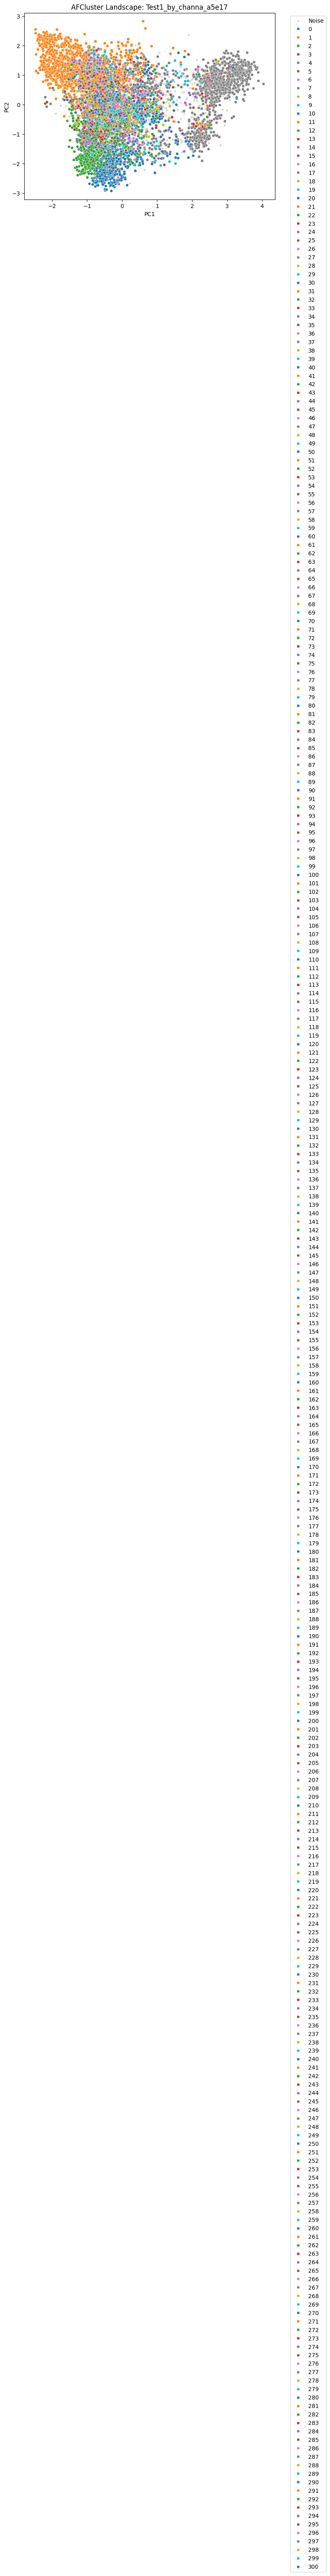

In [10]:
import seaborn as sns

# Perform PCA for visualization
pca = PCA(n_components=2)
coords = pca.fit_transform(ohe_seqs)
df['PC1'] = coords[:, 0]
df['PC2'] = coords[:, 1]

plt.figure(figsize=(8, 6))
# Plot Noise (-1) in gray
sns.scatterplot(data=df[df.dbscan_label == -1], x='PC1', y='PC2', color='lightgray', s=15, label='Noise')
# Plot Clusters
sns.scatterplot(data=df[df.dbscan_label >= 0], x='PC1', y='PC2', hue='dbscan_label', palette='tab10', s=25)

plt.title(f"AFCluster Landscape: {jobname}")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [11]:
import os
from pathlib import Path
import colabfold.batch as cf_batch

# Check what default_data_dir colabfold uses
print("=== ColabFold default_data_dir ===")
print(cf_batch.default_data_dir)

# Download monomer ptm params (these are the ones Module 4 needs)
print("\n=== Downloading AlphaFold monomer params ===")
print("This downloads params_model_1_ptm through model_5_ptm")
print("File size: ~3.5GB — this will take 5-10 minutes on Colab\n")

try:
    cf_batch.download_alphafold_params(
        model_type = "alphafold2_ptm",
        data_dir   = cf_batch.default_data_dir
    )
    print("\n✅ Download complete")

    # Confirm files are present
    params_dir = Path(cf_batch.default_data_dir) / "params"
    npz_files  = sorted([f for f in os.listdir(params_dir)
                         if f.endswith(".npz")])
    print(f"✅ Params dir: {params_dir}")
    print(f"✅ Files found: {npz_files}")

except Exception as e:
    print(f"❌ Download failed: {e}")
    import traceback
    traceback.print_exc()

=== ColabFold default_data_dir ===
/root/.cache/colabfold

=== Downloading AlphaFold monomer params ===
This downloads params_model_1_ptm through model_5_ptm
File size: ~3.5GB — this will take 5-10 minutes on Colab




✅ Download complete
✅ Params dir: /root/.cache/colabfold/params
✅ Files found: ['params_model_1.npz', 'params_model_1_ptm.npz', 'params_model_2.npz', 'params_model_2_ptm.npz', 'params_model_3.npz', 'params_model_3_ptm.npz', 'params_model_4.npz', 'params_model_4_ptm.npz', 'params_model_5.npz', 'params_model_5_ptm.npz']


In [12]:
# ============================================================================
# CELL 9 — DROPOUT CONFIG
# ----------------------------------------------------------------------------
# This cell only sets configuration variables — no computation runs here.
# All variables are read by Cell 10 (Module 4).
# ============================================================================

# ----------------------------------------------------------------------------
# CONTROL 1: How many cluster sub-MSAs to use from Module 3 output.
#
# Module 3 saves files to cluster_output_msas/cluster_0.a3m, cluster_1.a3m...
# Set to an integer to use only the first N clusters.
# Set to None to use ALL clusters Module 3 produced.
# Recommended: start with 3–5 for a test run, then use None for full research.
# ----------------------------------------------------------------------------
N_CLUSTERS_TO_USE = 3        # int or None

# ----------------------------------------------------------------------------
# CONTROL 2: Number of stochastic ensemble structures per sub-MSA.
#
# Each ensemble member = one full AlphaFold forward pass with:
#   - dropout ACTIVE  (eval_dropout = True)
#   - freshly masked MSA columns
#   - unique random seed
# This is equivalent to AFSample2's --nstruct parameter.
# Recommended: 3 for testing, 10–20 for research.
# ----------------------------------------------------------------------------
N_ENSEMBLES_PER_CLUSTER = 3  # int, minimum 1

# ----------------------------------------------------------------------------
# CONTROL 3: MSA column masking fraction (AFSample2 --msa_rand_fraction).
#
# Fraction of aligned MSA columns replaced with residue index 20 (X=unknown).
# Applied to homologue rows only. Query row (row 0) is NEVER masked.
# AFSample2 experimentally validated range: 0.0 – 0.30
#   0.00 = pure dropout diversity only (fastest)
#   0.15 = AFSample2 default          (recommended)
#   0.30 = aggressive perturbation    (more diversity, lower mean pLDDT)
# ----------------------------------------------------------------------------
MSA_RAND_FRACTION = 0.15      # float, 0.0 to 0.30

# ----------------------------------------------------------------------------
# CONTROL 4: Base random seed.
# Each ensemble member i gets seed = DROPOUT_SEED_BASE + i
# Ensures reproducibility while giving each forward pass a unique seed.
# ----------------------------------------------------------------------------
DROPOUT_SEED_BASE = 42        # int

# ----------------------------------------------------------------------------
# CONTROL 5: AlphaFold params directory.
# Confirmed by your diagnostic: /root/.cache/colabfold/params
# Only change this if you see a params loading error in Module 4.
# ----------------------------------------------------------------------------
AF_DATA_DIR = "/root/.cache/colabfold"   # parent of the params/ folder

# ── Print summary ─────────────────────────────────────────────────────────
import os
clusters_dir = "cluster_output_msas"
if os.path.exists(clusters_dir):
    all_files   = sorted([f for f in os.listdir(clusters_dir)
                          if f.endswith(".a3m")])
    n_available = len(all_files)
else:
    n_available = 0

n_to_use = min(N_CLUSTERS_TO_USE, n_available) \
           if N_CLUSTERS_TO_USE is not None else n_available

print("=" * 60)
print("DROPOUT CONFIG SUMMARY")
print("=" * 60)
print(f"  Clusters available      : {n_available}")
print(f"  N_CLUSTERS_TO_USE       : {N_CLUSTERS_TO_USE}"
      f"  →  will use {n_to_use}")
print(f"  N_ENSEMBLES_PER_CLUSTER : {N_ENSEMBLES_PER_CLUSTER}")
print(f"  MSA_RAND_FRACTION       : {MSA_RAND_FRACTION}")
print(f"  DROPOUT_SEED_BASE       : {DROPOUT_SEED_BASE}")
print(f"  AF_DATA_DIR             : {AF_DATA_DIR}")
print(f"  AlphaFold models        : 5  (model_1 – model_5, alphafold2_ptm)")
print("-" * 60)
print(f"  Total forward passes    : "
      f"{n_to_use} clusters × "
      f"{N_ENSEMBLES_PER_CLUSTER} ensembles × 5 models"
      f" = {n_to_use * N_ENSEMBLES_PER_CLUSTER * 5}")
print("=" * 60)

if n_available == 0:
    print("\n⚠️  WARNING: cluster_output_msas/ is empty or missing.")
    print("   Run Module 3 before running Module 4.")

DROPOUT CONFIG SUMMARY
  Clusters available      : 301
  N_CLUSTERS_TO_USE       : 3  →  will use 3
  N_ENSEMBLES_PER_CLUSTER : 3
  MSA_RAND_FRACTION       : 0.15
  DROPOUT_SEED_BASE       : 42
  AF_DATA_DIR             : /root/.cache/colabfold
  AlphaFold models        : 5  (model_1 – model_5, alphafold2_ptm)
------------------------------------------------------------
  Total forward passes    : 3 clusters × 3 ensembles × 5 models = 45


✅ colabfold.batch imports successful
✅ load_models_and_params imported

MODULE 4: STOCHASTIC DROPOUT INFERENCE

── Loading AlphaFold model runners ──────────────────────────
   model_type    = alphafold2_ptm
   model_order   = [1, 2, 3, 4, 5]
   use_dropout   = True  ← eval_dropout=True on all runners
   AF_DATA_DIR   = /root/.cache/colabfold


✅ 5 model runners loaded with eval_dropout=True
   model_1  eval_dropout=True
   model_2  eval_dropout=True
   model_3  eval_dropout=True
   model_4  eval_dropout=True
   model_5  eval_dropout=True

── Cluster sub-MSAs ──────────────────────────────────────────
   Available : 301
   Selected  : 3
   Total predict_structure calls : 3 × 3 = 9
   (Each call runs all 5 models internally)


════════════════════════════════════════════════════════════
  CLUSTER 0  —  cluster_0.a3m
════════════════════════════════════════════════════════════
  Query length : 59
  Sequences in sub-MSA : 16
  feature_dict['msa'] shape : (16, 59)

  ── Ensemble 1/3  seed=

/tmp/ipykernel_863/1053723152.py:440: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


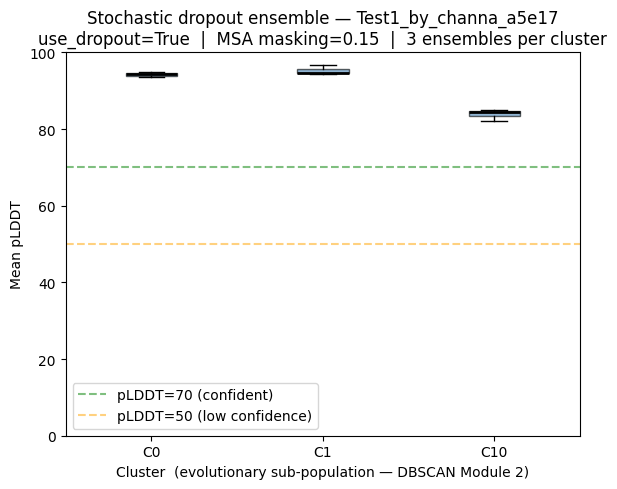


MODULE 4 COMPLETE
  PDB files  → dropout_predictions/Test1_by_channa_a5e17/cluster_*/
  Metadata   → dropout_predictions/Test1_by_channa_a5e17/all_predictions_meta.json
  Completed  : 9 / 9 ensemble runs


In [13]:
# ============================================================================
# CELL 10 — MODULE 4: STOCHASTIC DROPOUT INFERENCE
# ----------------------------------------------------------------------------
# Prerequisites:
#   Cell 1  → jobname, query_sequence
#   Cell 9  → N_CLUSTERS_TO_USE, N_ENSEMBLES_PER_CLUSTER,
#              MSA_RAND_FRACTION, DROPOUT_SEED_BASE, AF_DATA_DIR
#   Module 3 → cluster_output_msas/cluster_{id}.a3m
#
# Design:
#   - Uses colabfold.batch public API throughout (no alphafold.model.model
#     direct import) — this avoids the broken TF Lite .so files entirely
#   - load_models_and_params() is called with use_dropout=True, which sets
#     model_config.model.global_config.eval_dropout = True internally —
#     this is the exact AFSample2 mechanism
#   - MSA masking is applied to feature_dict['msa'] after generate_input_feature()
#     builds it — identical to AFSample2's masking loop:
#       for col in columns_to_randomize:
#           msa[1:, col] = np.array([20] * (msa.shape[0] - 1))
#   - predict_structure() runs the forward pass and saves PDB + JSON
#     automatically — we do not write files manually
# ============================================================================


# ============================================================================
# SECTION 1: IMPORTS
# All imports here are from colabfold.batch which is confirmed working.
# alphafold.model.model is NOT imported here — it is loaded inside
# load_models_and_params() as a deferred local import, which avoids
# the TF Lite broken .so chain entirely.
# ============================================================================

import os
import copy
import json
import time
import traceback
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# colabfold.batch — confirmed fully importable in your environment
from colabfold.batch import (
    generate_input_feature,   # builds feature_dict from a3m string
    predict_structure,        # runs inference, saves PDB + JSON
    set_model_type,           # resolves "auto" to correct model string
)
# from colabfold.input import unserialize_msa   # converts a3m string to MSA lists
from colabfold.batch import unserialize_msa

print("✅ colabfold.batch imports successful")

# load_models_and_params is imported here as a NAME ONLY reference.
# The actual alphafold.model.model import happens inside the function
# when it is first called — deferred exactly as colabfold.batch.run() does it.
# This is what prevents the TF Lite crash.
from colabfold.alphafold.models import load_models_and_params
print("✅ load_models_and_params imported")


# ============================================================================
# SECTION 2: CONSTANTS
# ============================================================================

# AlphaFold residue encoding (residue_constants.restypes order):
# A  R  N  D  C  Q  E  G  H  I  L  K  M  F  P  S  T  W  Y  V
# 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19
# Index 20 = X (unknown) — AFSample2 uses this for MSA column masking
UNKNOWN_IDX  = 20

# Model type for monomer with pTM head — confirmed present in your params dir:
# params_model_1_ptm.npz ... params_model_5_ptm.npz
MODEL_TYPE   = "alphafold2_ptm"

# All 5 models — same set AFSample2 uses by default for monomer
MODEL_ORDER  = [1, 2, 3, 4, 5]
NUM_MODELS   = 5

# max_seq=512 is ColabFold's default for alphafold2_ptm monomers
MAX_SEQ      = 512


# ============================================================================
# SECTION 3: HELPER — PARSE .a3m FILE
# ============================================================================

def read_a3m_file(a3m_path):
    """
    Read a .a3m file and return its raw string content.
    unserialize_msa() expects a list containing this string.
    """
    with open(a3m_path, "r") as fh:
        return fh.read()


def get_query_sequence_from_a3m(a3m_string):
    """
    Extract the query sequence (first sequence) from an a3m string.
    Discards lowercase insertion characters.
    Returns uppercase aligned sequence string.
    """
    for line in a3m_string.splitlines():
        line = line.strip()
        if not line or line.startswith(">"):
            continue
        # First non-header line = query sequence
        return "".join(c for c in line if c.isupper() or c == "-")
    return ""


# ============================================================================
# SECTION 4: HELPER — MSA COLUMN MASKING (AFSample2 exact logic)
# ============================================================================

def mask_msa_columns(feature_dict, msa_rand_fraction, rng):
    """
    Apply AFSample2's MSA column masking to feature_dict['msa'].

    Exact AFSample2 logic from run_afsample2.py:
        columns_to_randomize = np.random.choice(
            range(0, nres),
            size=int(nres * msa_rand_fraction),
            replace=False
        )
        for col in columns_to_randomize:
            msa[1:, col] = np.array([20] * (msa.shape[0] - 1))

    Rules:
      - Row 0 (query) is NEVER modified
      - Rows 1+ (homologues) are masked with index 20 (X = unknown)
      - Column selection is without replacement

    Parameters
    ----------
    feature_dict      : dict   output of generate_input_feature()
    msa_rand_fraction : float  fraction of columns to mask
    rng               : np.random.Generator  seeded for reproducibility

    Returns
    -------
    masked_dict  : dict  deep copy of feature_dict with masked msa
    masked_cols  : list  column indices that were masked (for logging)
    """
    masked_dict = copy.deepcopy(feature_dict)

    if msa_rand_fraction <= 0.0:
        return masked_dict, []

    msa       = masked_dict["msa"]
    n_seqs    = msa.shape[0]
    query_len = msa.shape[1]

    if n_seqs < 2:
        # Only query present — nothing to mask
        return masked_dict, []

    # AFSample2 exact column selection
    n_cols_to_mask = int(query_len * msa_rand_fraction)
    if n_cols_to_mask == 0:
        return masked_dict, []

    masked_cols = rng.choice(
        range(0, query_len),
        size=n_cols_to_mask,
        replace=False
    ).tolist()

    # AFSample2 exact masking — rows 1+ only, index 20 (X)
    for col in masked_cols:
        msa[1:, col] = np.array([UNKNOWN_IDX] * (n_seqs - 1))

    masked_dict["msa"] = msa
    return masked_dict, masked_cols


# ============================================================================
# SECTION 5: LOAD MODEL RUNNERS WITH use_dropout=True
# ============================================================================
# load_models_and_params() is called once and reused for all clusters
# and all ensemble members. This avoids recompiling JAX kernels.
#
# use_dropout=True is the single parameter that sets:
#   model_config.model.global_config.eval_dropout = True
# on every runner — confirmed in the models.py source.

print("\n" + "=" * 60)
print("MODULE 4: STOCHASTIC DROPOUT INFERENCE")
print("=" * 60)
print(f"\n── Loading AlphaFold model runners ──────────────────────────")
print(f"   model_type    = {MODEL_TYPE}")
print(f"   model_order   = {MODEL_ORDER}")
print(f"   use_dropout   = True  ← eval_dropout=True on all runners")
print(f"   AF_DATA_DIR   = {AF_DATA_DIR}\n")

model_runner_and_params = load_models_and_params(
    num_models    = NUM_MODELS,
    use_templates = False,          # matches your template_mode='none'
    num_recycles  = 3,              # matches ColabFold default
    model_order   = MODEL_ORDER,
    model_type    = MODEL_TYPE,
    data_dir      = Path(AF_DATA_DIR),
    use_dropout   = True,           # ← THE AFSAMPLE2 KEY FLAG
    max_seq       = MAX_SEQ,
    use_fuse      = True,
    use_bfloat16  = True,
    save_all      = False,
)

print(f"\n✅ {len(model_runner_and_params)} model runners loaded with "
      f"eval_dropout=True")
for model_name, runner, params in model_runner_and_params:
    dropout_status = runner.config.model.global_config.eval_dropout
    print(f"   {model_name}  eval_dropout={dropout_status}")


# ============================================================================
# SECTION 6: DISCOVER CLUSTER FILES FROM MODULE 3
# ============================================================================

clusters_dir = "cluster_output_msas"

if not os.path.exists(clusters_dir):
    raise FileNotFoundError(
        f"'{clusters_dir}' not found. Run Module 3 first."
    )

all_cluster_files = sorted([
    f for f in os.listdir(clusters_dir) if f.endswith(".a3m")
])

if not all_cluster_files:
    raise FileNotFoundError(
        f"No .a3m files in '{clusters_dir}'. Run Module 3 first."
    )

# Apply N_CLUSTERS_TO_USE limit from Cell 9
selected_files = (all_cluster_files[:N_CLUSTERS_TO_USE]
                  if N_CLUSTERS_TO_USE is not None
                  else all_cluster_files)

print(f"\n── Cluster sub-MSAs ──────────────────────────────────────────")
print(f"   Available : {len(all_cluster_files)}")
print(f"   Selected  : {len(selected_files)}")
total_runs = len(selected_files) * N_ENSEMBLES_PER_CLUSTER
print(f"   Total predict_structure calls : "
      f"{len(selected_files)} × {N_ENSEMBLES_PER_CLUSTER} = {total_runs}")
print(f"   (Each call runs all {NUM_MODELS} models internally)\n")


# ============================================================================
# SECTION 7: MAIN INFERENCE LOOP
# ============================================================================

dropout_dir = os.path.join("dropout_predictions", jobname)
os.makedirs(dropout_dir, exist_ok=True)

all_meta = []   # metadata for every completed prediction

for cluster_file in selected_files:

    cluster_id  = cluster_file.replace("cluster_", "").replace(".a3m", "")
    a3m_path    = os.path.join(clusters_dir, cluster_file)
    cluster_out = Path(dropout_dir) / f"cluster_{cluster_id}"
    cluster_out.mkdir(parents=True, exist_ok=True)

    print(f"\n{'═' * 60}")
    print(f"  CLUSTER {cluster_id}  —  {cluster_file}")
    print(f"{'═' * 60}")

    # ── Step 1: Read .a3m file ────────────────────────────────────────────
    a3m_string = read_a3m_file(a3m_path)
    cluster_query_seq = get_query_sequence_from_a3m(a3m_string)
    query_len = len(cluster_query_seq)
    print(f"  Query length : {query_len}")

    # ── Step 2: Build base feature dict via ColabFold API ─────────────────
    # unserialize_msa converts the a3m string into the unpaired_msa format
    # that generate_input_feature() expects — same path as colabfold.batch.run()
    try:
        (unpaired_msa,
         paired_msa,
         query_seqs_unique,
         query_seqs_cardinality,
         template_features) = unserialize_msa(
            [a3m_string],           # list of a3m strings
            cluster_query_seq,      # query sequence string
        )

        base_feature_dict, _ = generate_input_feature(
            query_seqs_unique      = query_seqs_unique,
            query_seqs_cardinality = query_seqs_cardinality,
            unpaired_msa           = unpaired_msa,
            paired_msa             = paired_msa,
            template_features      = template_features,
            is_complex             = False,
            model_type             = MODEL_TYPE,
            max_seq                = MAX_SEQ,
        )
    except Exception as e:
        print(f"  ❌ Feature generation failed for cluster {cluster_id}: {e}")
        traceback.print_exc()
        continue

    n_seqs = base_feature_dict["msa"].shape[0]
    print(f"  Sequences in sub-MSA : {n_seqs}")
    print(f"  feature_dict['msa'] shape : {base_feature_dict['msa'].shape}")

    cluster_meta = []

    # ── Step 3: Ensemble loop ──────────────────────────────────────────────
    for ensemble_idx in range(N_ENSEMBLES_PER_CLUSTER):

        # Seed formula mirrors AFSample2:
        # model_random_seed = model_index + random_seed * num_models
        ensemble_seed = ensemble_idx + DROPOUT_SEED_BASE * NUM_MODELS
        rng           = np.random.default_rng(ensemble_seed)

        print(f"\n  ── Ensemble {ensemble_idx + 1}/{N_ENSEMBLES_PER_CLUSTER}"
              f"  seed={ensemble_seed} ──")

        # ── Step 4: Apply AFSample2 MSA column masking ───────────────────
        # Deep copy base_feature_dict then mask feature_dict['msa']
        # This is identical to AFSample2's:
        #   for col in columns_to_randomize:
        #       msa[1:, col] = np.array([20] * (msa.shape[0] - 1))
        masked_feature_dict, masked_cols = mask_msa_columns(
            feature_dict      = base_feature_dict,
            msa_rand_fraction = MSA_RAND_FRACTION,
            rng               = rng,
        )
        print(f"     MSA columns masked : {len(masked_cols)} / {query_len}")

        # ── Step 5: Run predict_structure ────────────────────────────────
        # predict_structure() internally calls:
        #   model_runner.process_features(feature_dict, random_seed=seed)
        #   model_runner.predict(input_features, random_seed=seed)
        # Because eval_dropout=True on every runner (set in Section 5),
        # dropout is active during predict() — each call samples different
        # dropout masks in the Evoformer and structure module.
        # predict_structure saves PDB and JSON files automatically.

        prefix = (f"{jobname}"
                  f"_cluster{cluster_id}"
                  f"_ensemble{ensemble_idx:03d}"
                  f"_seed{ensemble_seed}"
                  f"_msa{MSA_RAND_FRACTION:.2f}"
                  f"_dropout")

        t0 = time.time()
        try:
            results = predict_structure(
                prefix                  = prefix,
                result_dir              = cluster_out,
                feature_dict            = masked_feature_dict,
                is_complex              = False,
                use_templates           = False,
                sequences_lengths       = [query_len],
                pad_len                 = query_len,
                model_type              = MODEL_TYPE,
                model_runner_and_params = model_runner_and_params,
                num_relax               = 0,
                rank_by                 = "plddt",
                random_seed             = ensemble_seed,
                num_seeds               = 1,
                stop_at_score           = 100,
                save_all                = False,
                save_recycles           = False,
            )
        except Exception as e:
            print(f"     ❌ predict_structure failed: {e}")
            traceback.print_exc()
            continue

        elapsed = time.time() - t0

        # ── Step 6: Extract metrics from results ──────────────────────────
        # predict_structure returns:
        # {"rank": [rank_strings], "metric": [metric_dicts], "result_files": [...]}
        # metric dicts contain mean_plddt, ptm — sorted best-first
        best_metric = results["metric"][0] if results["metric"] else {}
        mean_plddt  = best_metric.get("mean_plddt", float("nan"))
        ptm         = best_metric.get("ptm",        float("nan"))
        best_rank   = results["rank"][0] if results["rank"] else "unknown"

        print(f"     ✅ best rank  : {best_rank}")
        print(f"        pLDDT     : {mean_plddt:.2f}")
        print(f"        pTM       : {ptm:.3f}")
        print(f"        time      : {elapsed:.1f}s")
        print(f"        files     : {len(results['result_files'])} saved")

        meta = {
            "cluster_id"    : cluster_id,
            "ensemble_idx"  : ensemble_idx,
            "seed"          : ensemble_seed,
            "mean_plddt"    : round(float(mean_plddt), 3),
            "ptm"           : round(float(ptm),        3),
            "n_masked_cols" : len(masked_cols),
            "best_rank"     : best_rank,
            "elapsed_s"     : round(elapsed, 2),
            "result_files"  : [str(f) for f in results["result_files"]],
        }
        cluster_meta.append(meta)
        all_meta.append(meta)

    # ── Per-cluster summary ────────────────────────────────────────────────
    if cluster_meta:
        plddts = [m["mean_plddt"] for m in cluster_meta
                  if not np.isnan(m["mean_plddt"])]
        if plddts:
            print(f"\n  Cluster {cluster_id} summary:")
            print(f"  Completed : {len(plddts)} / {N_ENSEMBLES_PER_CLUSTER}")
            print(f"  pLDDT     : mean={np.mean(plddts):.2f}"
                  f"  std={np.std(plddts):.2f}"
                  f"  best={max(plddts):.2f}"
                  f"  worst={min(plddts):.2f}")


# ============================================================================
# SECTION 8: SAVE METADATA + SUMMARY PLOT
# ============================================================================

meta_path = os.path.join(dropout_dir, "all_predictions_meta.json")
with open(meta_path, "w") as fh:
    json.dump(all_meta, fh, indent=2)
print(f"\n✅ Metadata saved → {meta_path}")

# Summary boxplot: pLDDT per cluster
if all_meta:
    cluster_ids = sorted(set(m["cluster_id"] for m in all_meta))
    data_per_cluster = [
        [m["mean_plddt"] for m in all_meta
         if m["cluster_id"] == cid and not np.isnan(m["mean_plddt"])]
        for cid in cluster_ids
    ]
    valid = [(c, d) for c, d in zip(cluster_ids, data_per_cluster) if d]

    if valid:
        cids, vals = zip(*valid)
        fig, ax = plt.subplots(figsize=(max(6, len(cids) * 1.5), 5))
        ax.boxplot(
            vals,
            labels       = [f"C{c}" for c in cids],
            patch_artist = True,
            boxprops     = dict(facecolor="steelblue", alpha=0.6),
            medianprops  = dict(color="black", linewidth=2),
            flierprops   = dict(marker="o", markersize=3, alpha=0.5),
        )
        ax.axhline(70, color="green",  linestyle="--", alpha=0.5,
                   label="pLDDT=70 (confident)")
        ax.axhline(50, color="orange", linestyle="--", alpha=0.5,
                   label="pLDDT=50 (low confidence)")
        ax.set_xlabel(
            "Cluster  (evolutionary sub-population — DBSCAN Module 2)")
        ax.set_ylabel("Mean pLDDT")
        ax.set_ylim(0, 100)
        ax.set_title(
            f"Stochastic dropout ensemble — {jobname}\n"
            f"use_dropout=True  |  "
            f"MSA masking={MSA_RAND_FRACTION}  |  "
            f"{N_ENSEMBLES_PER_CLUSTER} ensembles per cluster"
        )
        ax.legend()
        plt.tight_layout()
        plt.show()

print(f"\n{'=' * 60}")
print(f"MODULE 4 COMPLETE")
print(f"{'=' * 60}")
print(f"  PDB files  → {dropout_dir}/cluster_*/")
print(f"  Metadata   → {meta_path}")
print(f"  Completed  : {len(all_meta)} / "
      f"{len(selected_files) * N_ENSEMBLES_PER_CLUSTER} ensemble runs")

In [14]:
import py3Dmol

def visualize_pdb(pdb_path):
    with open(pdb_path, 'r') as f:
        pdb_str = f.read()

    view = py3Dmol.view(width=800, height=400)
    view.addModel(pdb_str, 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}}) # 'spectrum' colors by N-to-C terminus
    view.zoomTo()
    return view

# Example: Replace with your actual path
pdb_to_show = "/content/dropout_predictions/Test1_by_channa_a5e17/cluster_0/Test1_by_channa_a5e17_cluster0_ensemble000_seed210_msa0.15_dropout_unrelaxed_rank_001_alphafold2_ptm_model_5_seed_210.pdb"
visualize_pdb(pdb_to_show)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [15]:
import py3Dmol

def visualize_pdb(pdb_path):
    with open(pdb_path, 'r') as f:
        pdb_str = f.read()

    view = py3Dmol.view(width=800, height=400)
    view.addModel(pdb_str, 'pdb')
    view.setStyle({'cartoon': {'color': 'spectrum'}}) # 'spectrum' colors by N-to-C terminus
    view.zoomTo()
    return view

# Example: Replace with your actual path
pdb_to_show = "/content/dropout_predictions/Test1_by_channa_a5e17/cluster_0/Test1_by_channa_a5e17_cluster0_ensemble001_seed211_msa0.15_dropout_unrelaxed_rank_005_alphafold2_ptm_model_1_seed_211.pdb"
visualize_pdb(pdb_to_show)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

To do:

1. Understand and recheck the DBSCAN module.
2. Remove old DBSCAN module.
3. Understand DROPOUT logic.
4. Check DROPOUT module.
5. Update the project readme.md
6. Calculate metrics and compare with existing tools.
7. Implementation a structural visulization module